In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

In [3]:
cc=pd.read_csv('//content/drive/MyDrive/Delinquency_prediction_datasett.csv')
cc.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [4]:
cc.isnull().sum()

,0
Customer_ID,0
Age,0
Income,39
Credit_Score,2
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,29
Debt_to_Income_Ratio,0
Employment_Status,0


In [5]:
cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [6]:
cc.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500.000000
mean,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,9.740000
std,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


In [7]:
cc["Income"]=cc["Income"].fillna(cc["Income"].mean()).astype(int)
cc["Income"].isnull().sum()

np.int64(0)

In [8]:
cc["Credit_Score"]=cc["Credit_Score"].fillna(cc["Credit_Score"].median()).astype(int)
cc['Credit_Score'].isnull().sum()

np.int64(0)

In [9]:
cc["Loan_Balance"]=cc["Loan_Balance"].fillna(cc["Loan_Balance"].mode()[0])

In [10]:
cc.isnull().sum()

,0
Customer_ID,0
Age,0
Income,0
Credit_Score,0
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,0
Debt_to_Income_Ratio,0
Employment_Status,0


In [11]:
cc

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580,398,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999,493,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416,500,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672,413,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524,487,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST0496,71,48307,688,0.486522,2,0,12707.0,0.373033,retired,9,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late
496,CUST0497,60,86180,836,0.608174,2,1,45595.0,0.291943,Unemployed,18,Student,Houston,On-time,On-time,Late,Late,Late,Missed
497,CUST0498,54,152326,847,0.676950,0,0,44449.0,0.104839,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed
498,CUST0499,50,105852,343,0.700643,2,1,11155.0,0.236477,Employed,11,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed


In [12]:
cc["Employment_Status"] = cc["Employment_Status"].replace("EMP", "Employed")

In [13]:
cc["Employment_Status"] = cc["Employment_Status"].replace("employed", "Employed")

In [14]:
cc["Employment_Status"].unique()

array(['Employed', 'Self-employed', 'Unemployed', 'retired'], dtype=object)

In [15]:
payment_cols = ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']
payment_mapping = {'Late': 1, 'On-time': 2, 'Missed': 0}

for col in payment_cols:
    cc[col] = cc[col].replace(payment_mapping)


/tmp/ipykernel_990/610602031.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cc[col] = cc[col].replace(payment_mapping)


In [16]:
cc.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580,398,0.390502,3,0,16310.0,0.317396,Employed,18,Student,Los Angeles,1,1,0,1,0,1
1,CUST0002,69,100999,493,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,0,0,1,0,2,2
2,CUST0003,46,188416,500,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,0,1,1,2,0,1
3,CUST0004,32,101672,413,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,1,0,1,0,1,1
4,CUST0005,60,38524,487,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,0,2,0,1,1,1


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

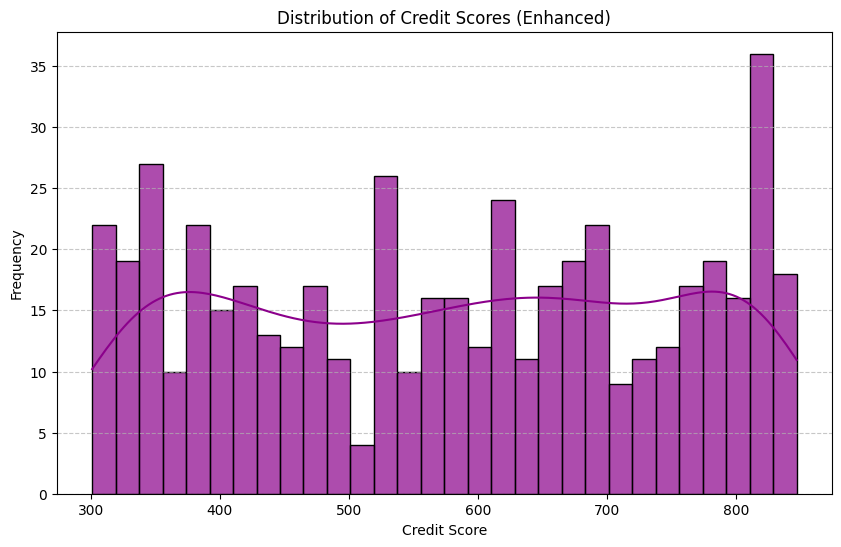

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(cc['Credit_Score'], bins=30, kde=True, color='darkmagenta', edgecolor='black', alpha=0.7)
plt.title("Distribution of Credit Scores (Enhanced)")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

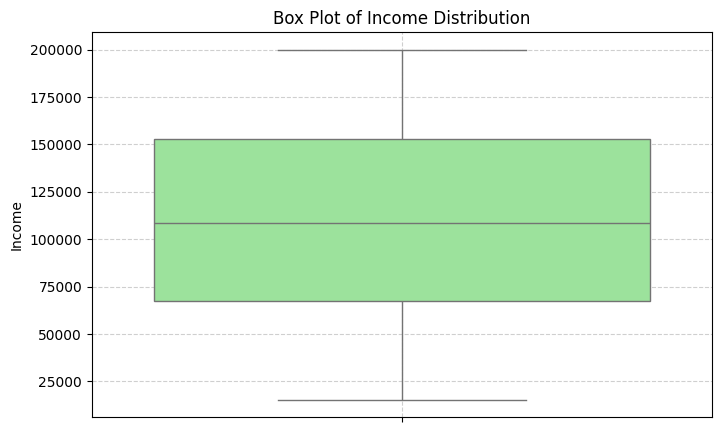

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=cc['Income'], color='lightgreen')
plt.title("Box Plot of Income Distribution")
plt.ylabel("Income")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

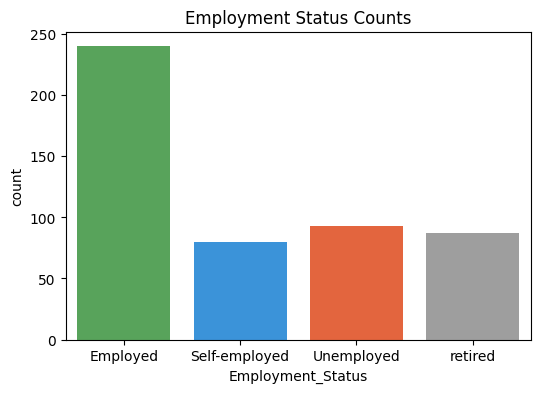

In [20]:
color_map = {'Employed': '#4CAF50', 'Unemployed': '#FF5722', 'Self-employed': '#2196F3', 'retired': '#9E9E9E'}
plt.figure(figsize=(6, 4))
sns.countplot(x=cc['Employment_Status'], hue=cc['Employment_Status'], palette=color_map, legend=False)
plt.title("Employment Status Counts")
plt.show()

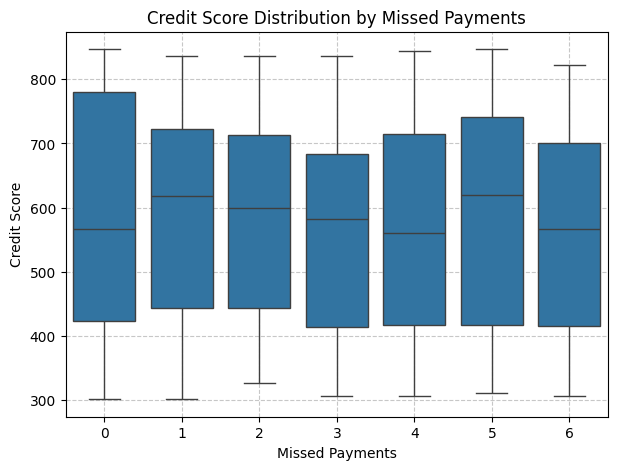

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x=cc['Missed_Payments'], y=cc['Credit_Score'])
plt.title("Credit Score Distribution by Missed Payments")
plt.xlabel("Missed Payments")
plt.ylabel("Credit Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Text(0.5, 1.0, 'Credit Utilization vs Credit Score')

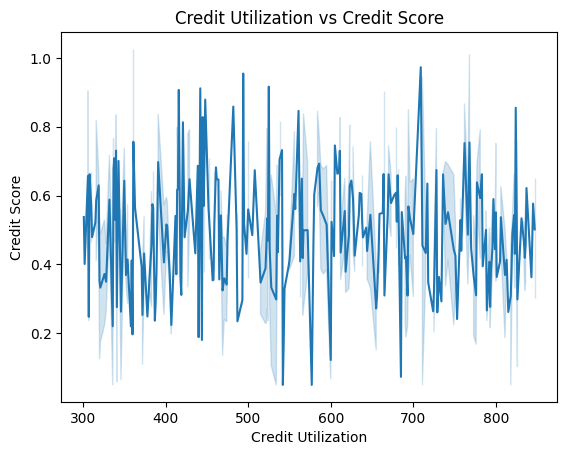

In [22]:
sns.lineplot(y=cc['Credit_Utilization'], x=cc['Credit_Score'])
plt.xlabel("Credit Utilization")
plt.ylabel("Credit Score")
plt.title("Credit Utilization vs Credit Score")

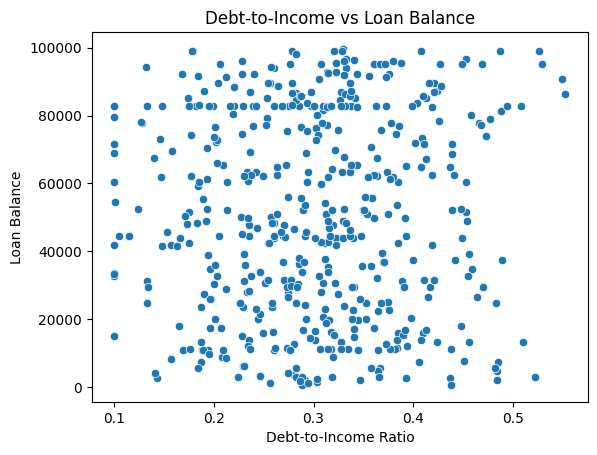

In [23]:
sns.scatterplot(x=cc['Debt_to_Income_Ratio'], y=cc['Loan_Balance'])
plt.title("Debt-to-Income vs Loan Balance")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Loan Balance")
plt.show()

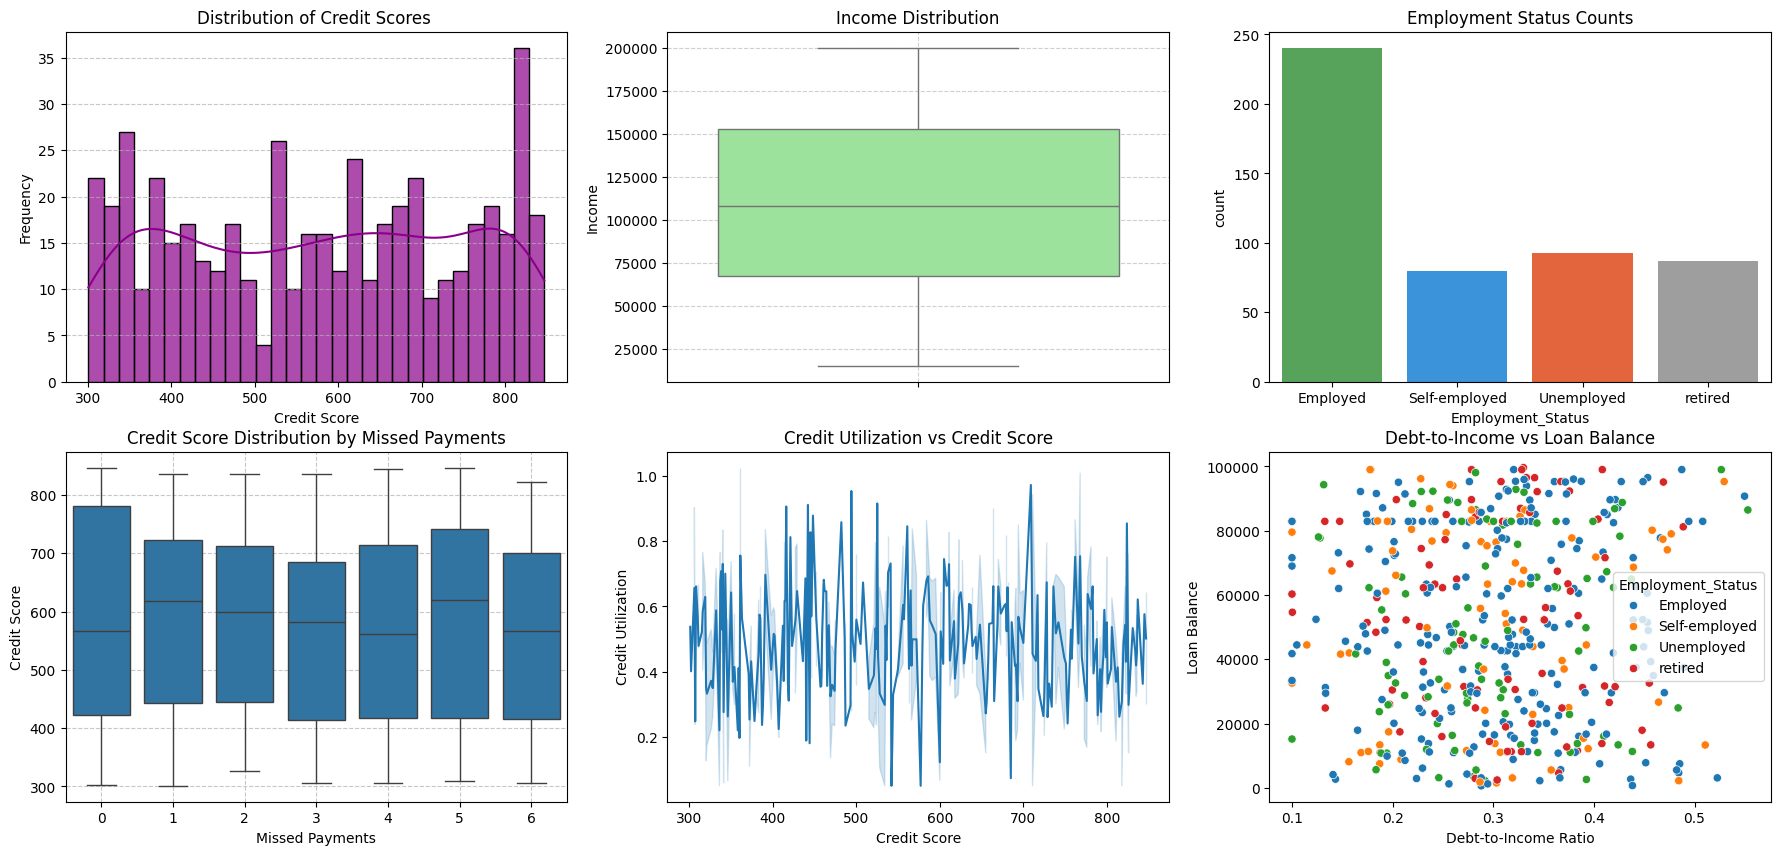

In [24]:
plt.figure(figsize=(22,10))
plt.subplot(2,3,1)
sns.histplot(cc['Credit_Score'], bins=30, kde=True, color='darkmagenta', edgecolor='black', alpha=0.7)
plt.title("Distribution of Credit Scores ")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.subplot(2,3,2)
sns.boxplot(y=cc['Income'], color='lightgreen')
plt.title("Income Distribution")
plt.ylabel("Income")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(2,3,3)
color_map = {'Employed': '#4CAF50', 'Unemployed': '#FF5722', 'Self-employed': '#2196F3', 'retired': '#9E9E9E'}
sns.countplot(x=cc['Employment_Status'], hue=cc['Employment_Status'], palette=color_map, legend=False)
plt.title("Employment Status Counts")
plt.subplot(2,3,4)
sns.boxplot(x=cc['Missed_Payments'], y=cc['Credit_Score'])
plt.title("Credit Score Distribution by Missed Payments")
plt.xlabel("Missed Payments")
plt.ylabel("Credit Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.subplot(2,3,5)
sns.lineplot(y=cc['Credit_Utilization'], x=cc['Credit_Score'])
plt.ylabel("Credit Utilization")
plt.xlabel("Credit Score")
plt.title("Credit Utilization vs Credit Score")
plt.subplot(2,3,6)
sns.scatterplot(x=cc['Debt_to_Income_Ratio'], y=cc['Loan_Balance'], data=cc, hue='Employment_Status')
plt.title("Debt-to-Income vs Loan Balance")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Loan Balance")
plt.show()

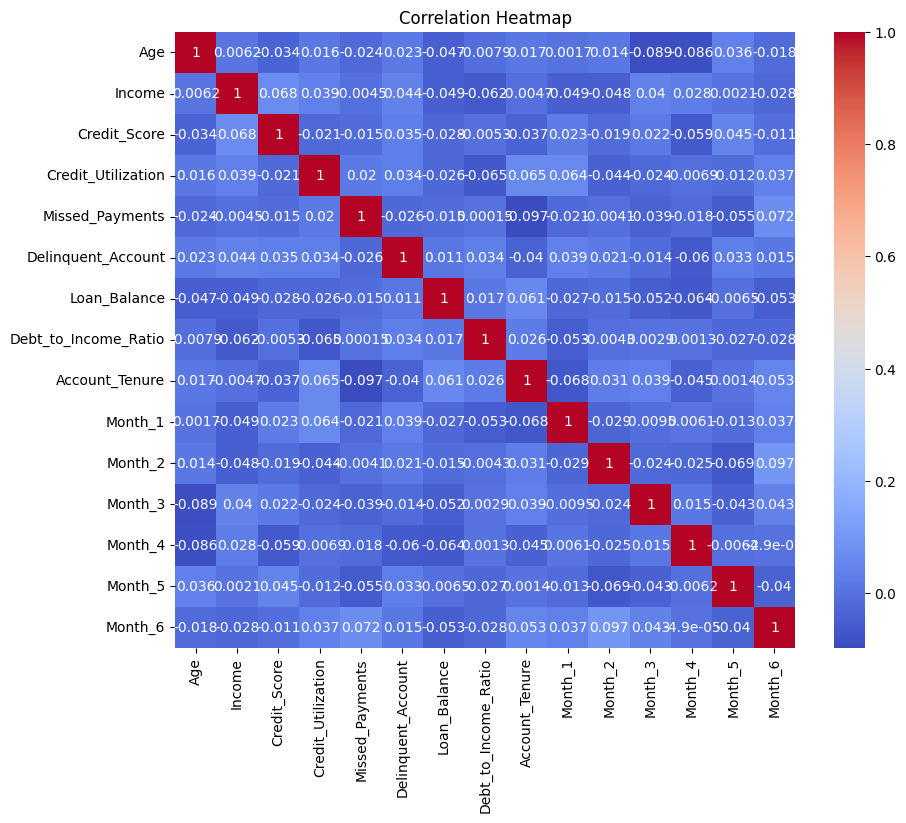

In [25]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cc.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

   Month_1  Month_2  Month_3  Month_4  Month_5  Month_6
0      164      167      162      160      187      168
1      159      173      169      181      151      172
2      177      160      169      159      162      160


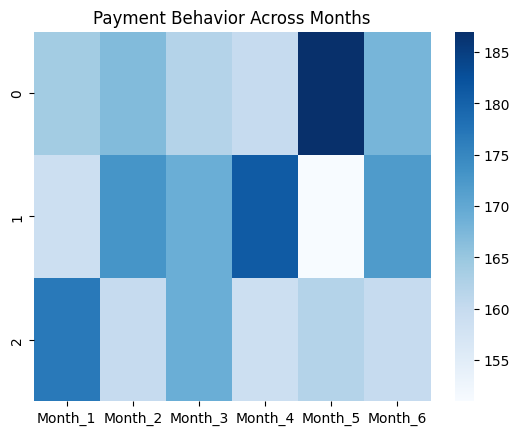

In [26]:
# Count payment statuses across months
payment_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6']
payment_counts = cc[payment_cols].apply(pd.Series.value_counts).fillna(0)

print(payment_counts)

# Heatmap of payment behavior
sns.heatmap(payment_counts, cmap="Blues")
plt.title("Payment Behavior Across Months")
plt.show()

RISK CONDITIONS

In [27]:
condition_credit_score = cc['Credit_Score'] < 450
condition_credit_utilization = cc['Credit_Utilization'] > 0.50
condition_debt_to_income = cc['Debt_to_Income_Ratio'] > 0.45
condition_missed_payments = cc['Missed_Payments'] >= 4
cc

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580,398,0.390502,3,0,16310.0,0.317396,Employed,18,Student,Los Angeles,1,1,0,1,0,1
1,CUST0002,69,100999,493,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,0,0,1,0,2,2
2,CUST0003,46,188416,500,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,0,1,1,2,0,1
3,CUST0004,32,101672,413,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,1,0,1,0,1,1
4,CUST0005,60,38524,487,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,0,2,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST0496,71,48307,688,0.486522,2,0,12707.0,0.373033,retired,9,Business,Phoenix,2,2,0,2,2,1
496,CUST0497,60,86180,836,0.608174,2,1,45595.0,0.291943,Unemployed,18,Student,Houston,2,2,1,1,1,0
497,CUST0498,54,152326,847,0.676950,0,0,44449.0,0.104839,Employed,16,Student,Phoenix,2,1,1,2,1,0
498,CUST0499,50,105852,343,0.700643,2,1,11155.0,0.236477,Employed,11,Student,Phoenix,1,2,1,0,2,0


In [28]:
risk_conditions = pd.DataFrame({
    'Credit_Score_Low': condition_credit_score,
    'Credit_Utilization_High': condition_credit_utilization,
    'Debt_to_Income_High': condition_debt_to_income,
    'Missed_Payments_High': condition_missed_payments
})

cc['Number_of_Risk_Conditions'] = risk_conditions.sum(axis=1)

cc['High_Risk_Flag'] = cc['Number_of_Risk_Conditions'] >= 3
cc['Medium_Risk_Flag'] = cc['Number_of_Risk_Conditions'] == 2

print("High Risk Customers:", cc['High_Risk_Flag'].sum())
print("Medium Risk Customers:", cc['Medium_Risk_Flag'].sum())
print("\nHead of the updated DataFrame:")
print(cc.head())

High Risk Customers: 37
Medium Risk Customers: 151

Head of the updated DataFrame:
  Customer_ID  Age  Income  Credit_Score  Credit_Utilization  Missed_Payments  \
0    CUST0001   56  165580           398            0.390502                3   
1    CUST0002   69  100999           493            0.312444                6   
2    CUST0003   46  188416           500            0.359930                0   
3    CUST0004   32  101672           413            0.371400                3   
4    CUST0005   60   38524           487            0.234716                2   

   Delinquent_Account  Loan_Balance  Debt_to_Income_Ratio Employment_Status  \
0                   0       16310.0              0.317396          Employed   
1                   1       17401.0              0.196093     Self-employed   
2                   0       13761.0              0.301655     Self-employed   
3                   0       88778.0              0.264794        Unemployed   
4                   0       13316.0

### High-Risk and Medium-Risk Customers by Location

In [29]:
risk_by_location = cc.groupby('Location')[['High_Risk_Flag', 'Medium_Risk_Flag']].sum().astype(int)
print(risk_by_location)

             High_Risk_Flag  Medium_Risk_Flag
Location                                     
Chicago                   8                28
Houston                   3                41
Los Angeles               8                29
New York                  9                25
Phoenix                   9                28


In [30]:
risk_by_location = cc.groupby('Location')[['High_Risk_Flag', 'Medium_Risk_Flag']].sum().astype(int)
print(risk_by_location)

             High_Risk_Flag  Medium_Risk_Flag
Location                                     
Chicago                   8                28
Houston                   3                41
Los Angeles               8                29
New York                  9                25
Phoenix                   9                28


In [31]:
cc

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Number_of_Risk_Conditions,High_Risk_Flag,Medium_Risk_Flag
0,CUST0001,56,165580,398,0.390502,3,0,16310.0,0.317396,Employed,...,Los Angeles,1,1,0,1,0,1,1,False,False
1,CUST0002,69,100999,493,0.312444,6,1,17401.0,0.196093,Self-employed,...,Phoenix,0,0,1,0,2,2,1,False,False
2,CUST0003,46,188416,500,0.359930,0,0,13761.0,0.301655,Self-employed,...,Chicago,0,1,1,2,0,1,0,False,False
3,CUST0004,32,101672,413,0.371400,3,0,88778.0,0.264794,Unemployed,...,Phoenix,1,0,1,0,1,1,1,False,False
4,CUST0005,60,38524,487,0.234716,2,0,13316.0,0.510583,Self-employed,...,Phoenix,0,2,0,1,1,1,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST0496,71,48307,688,0.486522,2,0,12707.0,0.373033,retired,...,Phoenix,2,2,0,2,2,1,0,False,False
496,CUST0497,60,86180,836,0.608174,2,1,45595.0,0.291943,Unemployed,...,Houston,2,2,1,1,1,0,1,False,False
497,CUST0498,54,152326,847,0.676950,0,0,44449.0,0.104839,Employed,...,Phoenix,2,1,1,2,1,0,1,False,False
498,CUST0499,50,105852,343,0.700643,2,1,11155.0,0.236477,Employed,...,Phoenix,1,2,1,0,2,0,2,False,True


In [32]:
cc['Medium_Risk_Flag']

,Medium_Risk_Flag
0,False
1,False
2,False
3,False
4,False
...,...
495,False
496,False
497,False
498,True


In [33]:
high_risk_customers = cc[cc['High_Risk_Flag'] == True]
print("Details of High Risk Customers:")
display(high_risk_customers)

Details of High Risk Customers:


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Number_of_Risk_Conditions,High_Risk_Flag,Medium_Risk_Flag
7,CUST0008,56,123215,415,0.532715,5,0,55776.0,0.358695,Employed,...,New York,2,2,2,1,0,1,3,True,False
10,CUST0011,28,42532,340,0.834456,4,0,82909.0,0.269559,Unemployed,...,Chicago,2,1,0,0,2,1,3,True,False
33,CUST0034,44,99076,440,0.188677,4,0,99005.0,0.487302,Employed,...,Houston,0,1,1,0,2,0,3,True,False
58,CUST0059,70,81040,401,0.559610,4,0,63443.0,0.374215,retired,...,Chicago,1,0,0,0,1,0,3,True,False
74,CUST0075,19,159188,835,0.505224,5,0,96507.0,0.453436,Employed,...,Los Angeles,2,2,2,0,2,2,3,True,False
105,CUST0106,62,99076,340,0.626524,6,0,30443.0,0.199682,retired,...,New York,1,1,1,0,0,0,3,True,False
108,CUST0109,32,19748,354,0.237544,6,0,29584.0,0.469949,Employed,...,Phoenix,0,1,2,1,0,1,3,True,False
111,CUST0112,42,16015,332,0.555666,5,0,8828.0,0.208318,Self-employed,...,Los Angeles,1,0,1,1,1,2,3,True,False
134,CUST0135,29,16252,441,0.576072,4,0,96056.0,0.379760,Employed,...,Los Angeles,1,2,1,2,0,1,3,True,False
138,CUST0139,72,138961,402,0.583641,5,1,42556.0,0.384901,Unemployed,...,Chicago,0,2,2,1,1,2,3,True,False


In [34]:
direct_high_risk_customer_ids = cc[cc['High_Risk_Flag'] == True]['Customer_ID']
print("Customer IDs of High Risk Customers (Directly):")
display(direct_high_risk_customer_ids)

Customer IDs of High Risk Customers (Directly):


,Customer_ID
7,CUST0008
10,CUST0011
33,CUST0034
58,CUST0059
74,CUST0075
105,CUST0106
108,CUST0109
111,CUST0112
134,CUST0135
138,CUST0139


In [35]:
cc.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Number_of_Risk_Conditions,High_Risk_Flag,Medium_Risk_Flag
0,CUST0001,56,165580,398,0.390502,3,0,16310.0,0.317396,Employed,...,Los Angeles,1,1,0,1,0,1,1,False,False
1,CUST0002,69,100999,493,0.312444,6,1,17401.0,0.196093,Self-employed,...,Phoenix,0,0,1,0,2,2,1,False,False
2,CUST0003,46,188416,500,0.359930,0,0,13761.0,0.301655,Self-employed,...,Chicago,0,1,1,2,0,1,0,False,False
3,CUST0004,32,101672,413,0.371400,3,0,88778.0,0.264794,Unemployed,...,Phoenix,1,0,1,0,1,1,1,False,False
4,CUST0005,60,38524,487,0.234716,2,0,13316.0,0.510583,Self-employed,...,Phoenix,0,2,0,1,1,1,1,False,False


In [36]:
((cc['Credit_Score'] < 400) & (cc['Credit_Utilization'] > 0.80)).sum()

np.int64(5)

In [37]:
cc['Customer_ID'].count()

np.int64(500)

In [38]:
cc.query('Credit_Score < 400 & Credit_Utilization > 0.80')

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Number_of_Risk_Conditions,High_Risk_Flag,Medium_Risk_Flag
10,CUST0011,28,42532,340,0.834456,4,0,82909.0,0.269559,Unemployed,...,Chicago,2,1,0,0,2,1,3,True,False
89,CUST0090,65,127856,361,1.025843,2,0,2200.0,0.346267,Employed,...,Chicago,2,1,2,0,0,2,2,False,True
292,CUST0293,49,38061,316,1.002482,1,0,95267.0,0.448824,Employed,...,Chicago,1,1,1,1,0,0,2,False,True
320,CUST0321,18,53513,391,0.835958,2,0,82382.0,0.343389,Unemployed,...,Phoenix,0,2,1,0,0,1,2,False,True
401,CUST0402,36,107658,306,0.903793,4,0,55345.0,0.189194,Unemployed,...,Los Angeles,2,0,0,2,1,1,3,True,False
